# Практическая работа №3

## Подготовка данных

In [381]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import sqrt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import GridSearchCV

In [382]:
data = pd.read_csv("../data/Data_for_UCI_named.csv")
data

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.9591,3.0799,8.3810,9.7808,3.7631,-0.7826,-1.2574,-1.7231,0.6505,0.8596,0.8874,0.9580,0.0553,unstable
1,9.3041,4.9025,3.0475,1.3694,5.0678,-1.9401,-1.8727,-1.2550,0.4134,0.8624,0.5621,0.7818,-0.0060,stable
2,8.9717,8.8484,3.0465,1.2145,3.4052,-1.2075,-1.2772,-0.9205,0.1630,0.7667,0.8394,0.1099,0.0035,unstable
3,0.7164,7.6696,4.4866,2.3406,3.9638,-1.0275,-1.9389,-0.9974,0.4462,0.9767,0.9294,0.3627,0.0289,unstable
4,3.1341,7.6088,4.9438,9.8576,3.5258,-1.1255,-1.8460,-0.5543,0.7971,0.4554,0.6569,0.8209,0.0499,unstable
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2.9304,9.4876,2.3765,6.1878,3.3434,-0.6581,-1.4491,-1.2363,0.6017,0.7796,0.8135,0.6084,0.0239,unstable
9996,3.3923,1.2748,2.9549,6.8948,4.3495,-1.6637,-0.9524,-1.7334,0.5021,0.5672,0.2859,0.3661,-0.0258,stable
9997,2.3640,2.8420,8.7764,1.0089,4.3000,-1.3807,-0.9439,-1.9754,0.4878,0.9865,0.1493,0.1460,-0.0318,stable
9998,9.6315,3.9944,2.7571,7.8213,2.5148,-0.9663,-0.6499,-0.8985,0.3652,0.5876,0.8891,0.8184,0.0378,unstable


In [383]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  str    
dtypes: float64(13), str(1)
memory usage: 1.1 MB


Пропущенных данных нет

In [384]:
stabf_dict = {
            "stable": 0,
            "unstable": 1}

data['stabf'] = data['stabf'].map(stabf_dict).astype("int32")

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  int32  
dtypes: float64(13), int32(1)
memory usage: 1.0 MB


## EDA

/tmp/ipykernel_3308/2633376017.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()


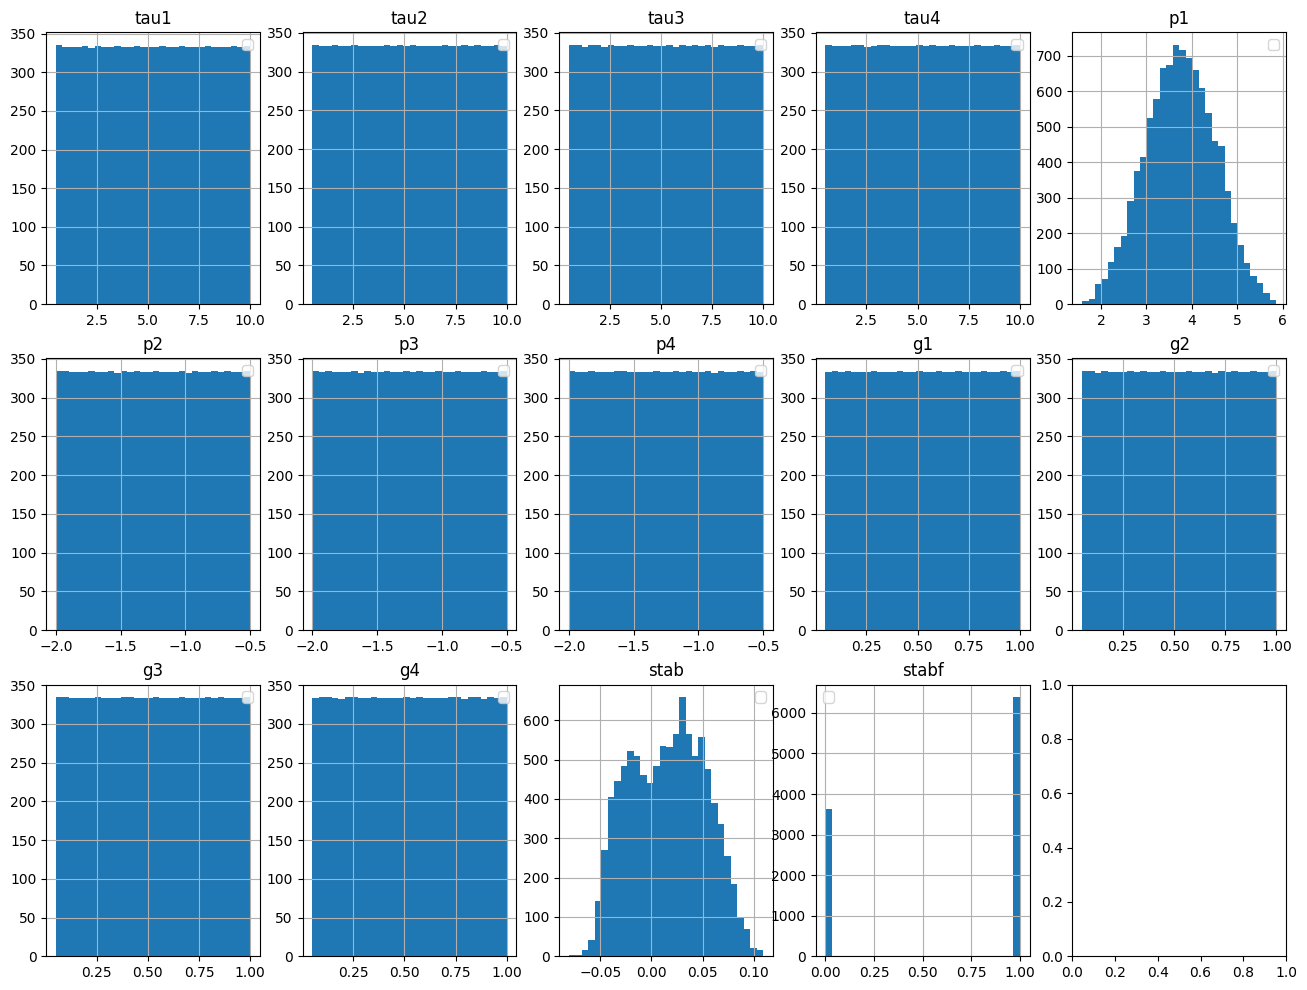

In [385]:
fig, axes = plt.subplots(3, 5, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(data.columns):
    data[col].hist(ax=axes[i], bins=30)
    axes[i].set_title(col)
    axes[i].legend()

Из графиков видно, что:
- нормальное распределение имеют только `p1`, `stab` (бимодальное распеределене).
- `stabf` представлен 2 группами. состояния `1 (stable)` больше, чем `0 (unstable)`
- Остальные атрибуты представлены равномерными распределениями
- Выбросов нет - данные "чистые"

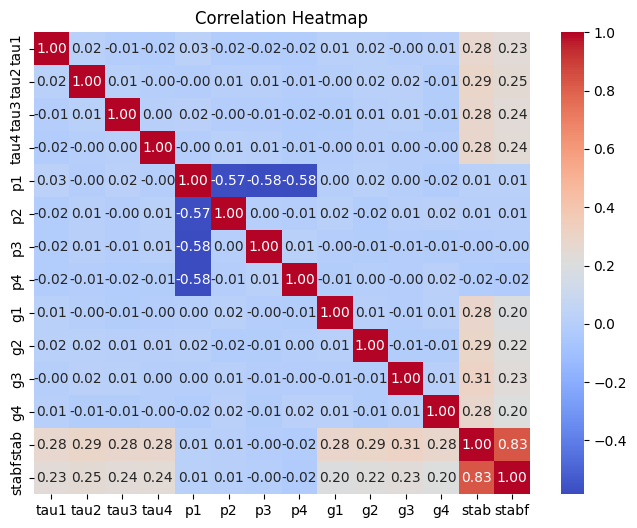

In [386]:
corr_matrix = data.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

Из тепловой карты видно, что:

- `p1`, `p2`, `p3`, `p4` между собой отрицательно коррелируют (-0.57, -0.58, -0.58), но при почти не коррелируют с целевым признаком `stab`
- `stab` и `stabf` сильно коррелируют между собой (0.83)
- Остальные атрибуты между собой почти не коррелируют и, при этом слабо коррелируют с целевым признаком `stab` (от 0.2 до 0.3)

In [387]:
features = data.drop("stab", axis=1)

vif_data = pd.DataFrame()
vif_data["VIF"] = [variance_inflation_factor(features.values, i) for i in range(features.shape[1])]
vif_data["Атрибут"] = features.columns
vif_data

/home/daniil/Рабочий стол/programing/master/mlbd/venv/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,VIF,Атрибут
0,4.5962,tau1
1,4.5582,tau2
2,4.5734,tau3
3,4.5321,tau4
4,inf,p1
5,inf,p2
6,inf,p3
7,inf,p4
8,4.4626,g1
9,4.5343,g2


Выводы  из теловой карты подствердились. `p1`, `p2`, `p3`, `p4` имеют очень высокую степень мультиколлениарности(inf). Остальные имеют низкую мультиколлениарность (4-4.6)

## Регуляризация моделей

**Вспомогательные функции**

In [388]:
def calculate_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    stats = {
        'R^2': r2,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    }
        
    return stats

def show_params(method):
    X_train_columns = ['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 
                       'g1', 'g2', 'g3', 'g4', 'stabf']
    
    if hasattr(method, 'best_estimator_'):
        model = method.best_estimator_
        model_name = method.best_estimator_.__class__.__name__
    else:
        model = method
        model_name = method.__class__.__name__
    
    coefs = pd.DataFrame({
        'Features': X_train_columns,
        'Coefficient': model.coef_
    })

    plt.figure(figsize=(10, 5))
    sns.barplot(data=coefs, x='Features', y='Coefficient', palette='viridis')
    plt.title(f"{model_name} Regression Coefficients")
    plt.ylabel("Coefficient Value")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

param_grid = {'alpha': [0.00001, 0.0001, 0.001, 0.01, 0.1, 1.0, 2.0]}

In [389]:
X = features
y = data["stab"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

**Линейная регрессия**

/tmp/ipykernel_3308/2574307532.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coefs, x='Features', y='Coefficient', palette='viridis')


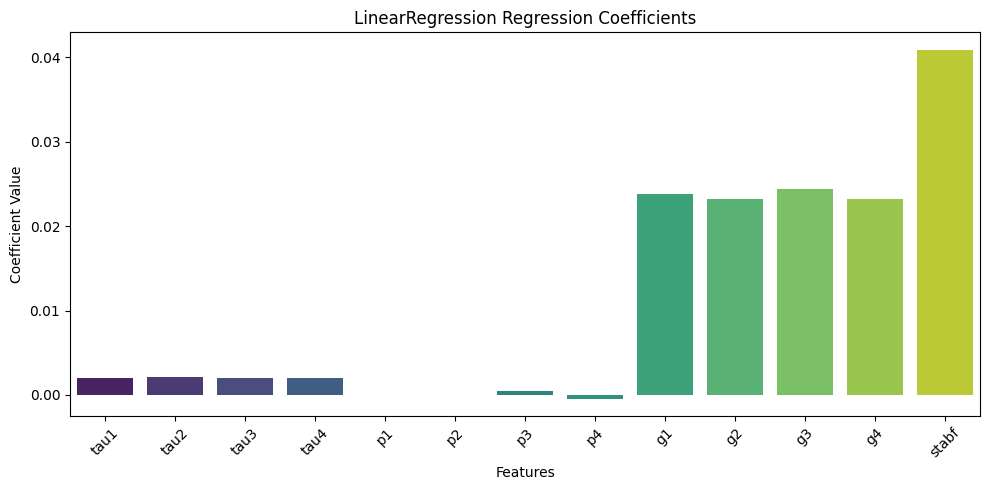

In [390]:
lr = LinearRegression().fit(X_train, y_train)
show_params(lr)

**Ridge**

{'alpha': 1.0}


/tmp/ipykernel_3308/2574307532.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coefs, x='Features', y='Coefficient', palette='viridis')


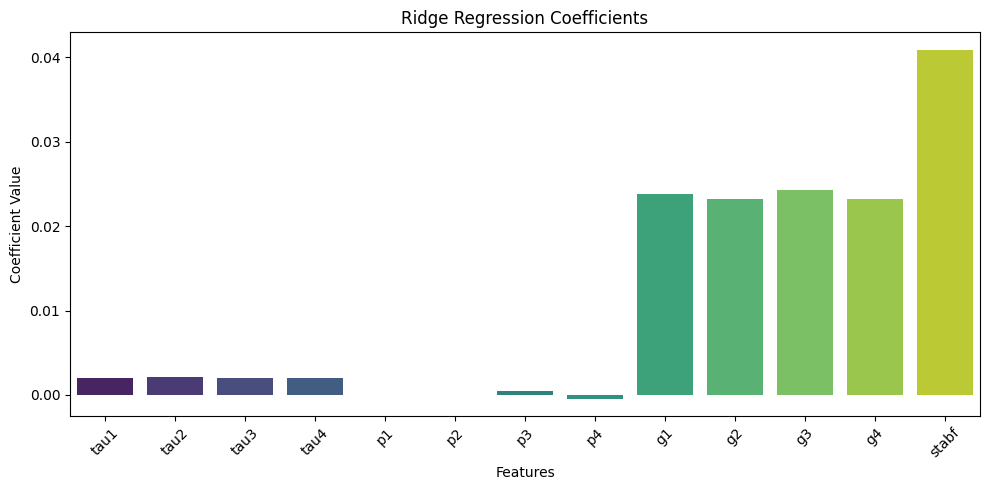

In [391]:
ridge = GridSearchCV(Ridge(), param_grid, cv=5, scoring='r2')
ridge.fit(X_train, y_train)
print(ridge.best_params_)
show_params(ridge)

**Lasso**

{'alpha': 1e-05}


/tmp/ipykernel_3308/2574307532.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coefs, x='Features', y='Coefficient', palette='viridis')


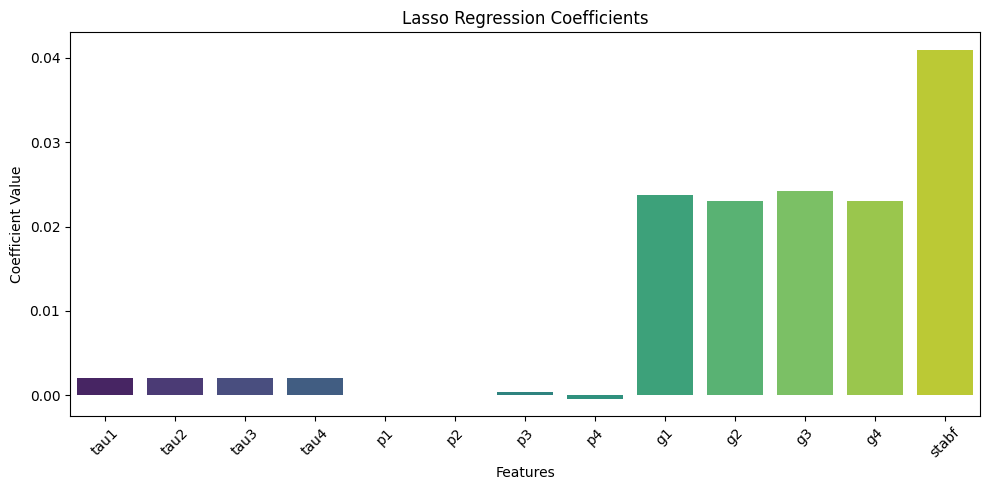

In [392]:
lasso = GridSearchCV(Lasso(), param_grid, cv=5, scoring='r2')
lasso.fit(X_train, y_train)
print(lasso.best_params_)
show_params(lasso)

**ElasticNet**

{'alpha': 1e-05}


/tmp/ipykernel_3308/2574307532.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coefs, x='Features', y='Coefficient', palette='viridis')


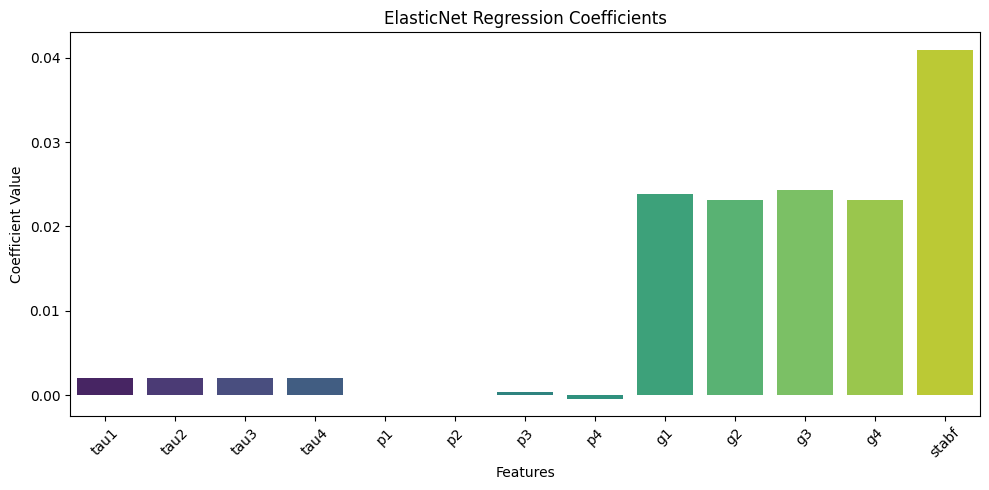

In [393]:
elastic = GridSearchCV(ElasticNet(), param_grid, cv=5, scoring='r2')
elastic.fit(X_train, y_train)
print(elastic.best_params_)
show_params(elastic)

Из графика видно, что (почти все графики идентичны):

- мултиколлениарные признаки `p1`, `p2`, `p3`, `p3` имеют коэффициент практическ 0, что свидетесльтвует о их неважности (коэффициенты при `p1` и `p2` раны 0)
- признки `tau1`, `tau2`, `tau3`, `tau4` имеют чуть большие коэффициенты, но при этом они минимальны из всех
- признаки `g1`, `g2`, `g3`, `g4` значительно большие коэффициенты
- признк `stabf` имеет наибольший коэффициент из всех, что свидетельствует о его наибольшей значимости

# Финальная таблица

In [394]:
results = []
models = {
    "Linear Regression": lr,
    "Ridge": ridge,
    "lasso": lasso,
    "ElasticNet": elastic
}

for model_name, model in models.items():
    train_metrics = calculate_metrics(y_train, model.predict(X_train))
    test_metrics = calculate_metrics(y_test, model.predict(X_test))
    
    results.append({
        'Регрессор': model_name,
        'Train': {
            'R^2': train_metrics['R^2'],
            'MSE': train_metrics['MSE'],
            'RMSE': train_metrics['RMSE'],
            'MAE': train_metrics['MAE'],
            'MAPE': train_metrics['MAPE']
        },
        'Test': {
            'R^2': test_metrics['R^2'],
            'MSE': test_metrics['MSE'],
            'RMSE': test_metrics['RMSE'],
            'MAE': test_metrics['MAE'],
            'MAPE': test_metrics['MAPE']
        }
    })

df_train = pd.DataFrame([r['Train'] for r in results])
df_test = pd.DataFrame([r['Test'] for r in results])

final_metrics = pd.concat({
    'Train Data': df_train,
    'Test Data': df_test
}, axis=1)

final_metrics.insert(0, 'Регрессор', [r['Регрессор'] for r in results])

final_metrics = final_metrics.style.format({
    ('Train Data', 'R^2'): '{:.2f}',
    ('Train Data', 'MSE'): '{:.4f}',
    ('Train Data', 'RMSE'): '{:.4f}',
    ('Train Data', 'MAE'): '{:.4f}',
    ('Train Data', 'MAPE'): '{:.4f}',
    ('Test Data', 'R^2'): '{:.2f}',
    ('Test Data', 'MSE'): '{:.4f}',
    ('Test Data', 'RMSE'): '{:.4f}',
    ('Test Data', 'MAE'): '{:.4f}',
    ('Test Data', 'MAPE'): '{:.4f}',
    
})

final_metrics


**Вывод по таблице**

Анализируя таблицу метрик, можно сделать вывод, что все методы показали практически одинаковое хорошее качество. Более того, линейная регрессия справилась так же хорошо, как и методы регуляризации, хотя наличие мультиколлениарности должно было ухудшить её результаты.

Это произошло потому, что признаки с высокой мультиколлениарностью (p1, p2, p3, p4 с VIF = ∞) имеют очень слабую корреляцию с целевой переменной stab (около 0). Следовательно, несмотря на наличие сильной мультиколлениарности в данных, она не повлияла на качество прогноза, так как эти признаки практически не важны для предсказания целевой переменной.

При этом замечена странность, что в Test data и Train data показатели практически совпадают (что говорит об отсутствии переобучения), но при этом MAPE сильно отличается (на 10) (мне не хаватило времени разобраться почему так)

## Вывод

В ходе работы были сдела следующие шаги:

1. Были загружены данные. Они были в хорошем состоянии и дальнейшая обработка не требовалась, за исключением перевода `stabf` в int.
2. В EDA была проанаизирована тепловая карта и выявлены корреляции и мильтиколениарности (p1-p4), сделан VIF расчет
3. Проведены тренировки моделей, с выводом коэффициентов в гистограммы
4. Построена таблица со всеми требуемыми метриками, и сделан вывод, что все регрессоры отработали одиннаково хорошо